# Banking Transaction Intelligence & Fraud Detection pipeline

This notebook covers the complete machine learning lifecycle:
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building (Training & Evaluation)
5. Model Serialization

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#import from src directory for Data Loader and Risk Scoring 
sys.path.append(os.path.abspath('../src'))
from data_loader import get_processed_data
from risk_scoring import calculate_customer_risk_score

##Data Preprocessing
Load data using our defined data_loader and begin preprocessing.

In [2]:
#Load combined initial preprocessed data
df = get_processed_data('../data')
print(f"Data Shape: {df.shape}")
display(df.head())

Loaded 100 customers.
Loaded 100 accounts.
Loaded 500 transactions.
Loaded 500 fraud labels.
Merged dataframe has 500 rows and 16 columns.
Data Shape: (500, 16)


,transaction_id,account_id,transaction_amount,merchant_category,transaction_type,location,timestamp,fraud_flag,customer_id,account_type,balance,account_open_date,age,occupation,annual_income,city
0,T0001,A100,34263,Restaurant,Debit,Delhi,2026-02-01 20:00:00,0,C100,Current,406506,2021-07-29,29,Manager,1653713,Delhi
1,T0002,A031,17907,Groceries,Debit,Mumbai,2026-01-22 10:00:00,0,C031,Savings,476295,2020-01-17,34,Manager,1346963,Bangalore
2,T0003,A030,25202,Groceries,Credit,Bangalore,2026-02-14 04:00:00,0,C030,Savings,166616,2018-09-19,34,Analyst,1805575,Delhi
3,T0004,A043,35660,Entertainment,Credit,Bangalore,2026-01-30 13:00:00,0,C043,Savings,455150,2022-11-22,38,Consultant,1644194,Delhi
4,T0005,A099,77728,Restaurant,Credit,Hyderabad,2026-03-02 22:00:00,1,C099,Savings,445330,2019-06-15,41,Doctor,857034,Bangalore


## Feature Engineering
Creating behavioral patterns required for fraud detection and risk scoring.

In [3]:
def engineer_features(df_in):
    df_out = df_in.copy()
    
    if 'timestamp' in df_out.columns:
        df_out['timestamp'] = pd.to_datetime(df_out['timestamp'])
        df_out['hour'] = df_out['timestamp'].dt.hour
        df_out['day_of_week'] = df_out['timestamp'].dt.dayofweek
    
    if 'account_id' in df_out.columns:
        freq_map = df_out.groupby('account_id').size().to_dict()
        df_out['account_tx_frequency'] = df_out['account_id'].map(freq_map)
        
    if 'account_id' in df_out.columns and 'transaction_amount' in df_out.columns:
        avg_spend_map = df_out.groupby('account_id')['transaction_amount'].mean().to_dict()
        df_out['account_avg_spending'] = df_out['account_id'].map(avg_spend_map)
        
    if 'transaction_amount' in df_out.columns and 'account_avg_spending' in df_out.columns:
        df_out['unusual_tx_amount_ratio'] = df_out['transaction_amount'] / (df_out['account_avg_spending'] + 1e-5)
        
    if 'location' in df_out.columns and 'city' in df_out.columns:
        df_out['location_deviation'] = (df_out['location'] != df_out['city']).astype(int)
        
    if 'merchant_category' in df_out.columns and 'fraud_flag' in df_out.columns:
        category_risk = df_out.groupby('merchant_category')['fraud_flag'].mean().to_dict()
        df_out['merchant_risk_score'] = df_out['merchant_category'].map(category_risk).fillna(0)
    elif 'merchant_category' in df_out.columns:
         df_out['merchant_risk_score'] = 0.5
         
    if 'transaction_amount' in df_out.columns and 'balance' in df_out.columns:
         df_out['amount_to_balance_ratio'] = df_out['transaction_amount'] / (df_out['balance'] + 1e-5)

    return df_out

df_feat = engineer_features(df)
display(df_feat.head())

,transaction_id,account_id,transaction_amount,merchant_category,transaction_type,location,timestamp,fraud_flag,customer_id,account_type,...,annual_income,city,hour,day_of_week,account_tx_frequency,account_avg_spending,unusual_tx_amount_ratio,location_deviation,merchant_risk_score,amount_to_balance_ratio
0,T0001,A100,34263,Restaurant,Debit,Delhi,2026-02-01 20:00:00,0,C100,Current,...,1653713,Delhi,20,6,4,21096.500000,1.624108,0,0.087500,0.084287
1,T0002,A031,17907,Groceries,Debit,Mumbai,2026-01-22 10:00:00,0,C031,Savings,...,1346963,Bangalore,10,3,5,21934.200000,0.816396,1,0.000000,0.037596
2,T0003,A030,25202,Groceries,Credit,Bangalore,2026-02-14 04:00:00,0,C030,Savings,...,1805575,Delhi,4,5,10,32561.000000,0.773993,1,0.000000,0.151258
3,T0004,A043,35660,Entertainment,Credit,Bangalore,2026-01-30 13:00:00,0,C043,Savings,...,1644194,Delhi,13,4,8,34359.500000,1.037850,1,0.038462,0.078348
4,T0005,A099,77728,Restaurant,Credit,Hyderabad,2026-03-02 22:00:00,1,C099,Savings,...,857034,Bangalore,22,0,3,39361.666667,1.974713,1,0.087500,0.174540


In [4]:
#Save featured data to CSV for Streamlit to consume easily
df_feat.to_csv('../data/featured_data.csv', index=False)
print("Saved featured data to ../data/featured_data.csv")

Saved featured data to ../data/featured_data.csv


## Exploratory Data Analysis (EDA)

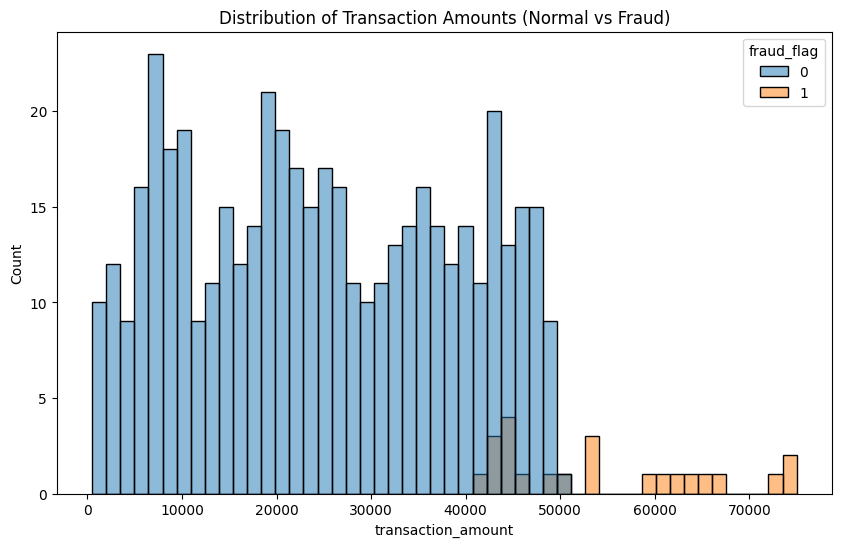

In [5]:
#Distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(data=df_feat[df_feat['transaction_amount'] < df_feat['transaction_amount'].quantile(0.99)], x='transaction_amount', hue='fraud_flag', bins=50)
plt.title('Distribution of Transaction Amounts (Normal vs Fraud)')
plt.show()

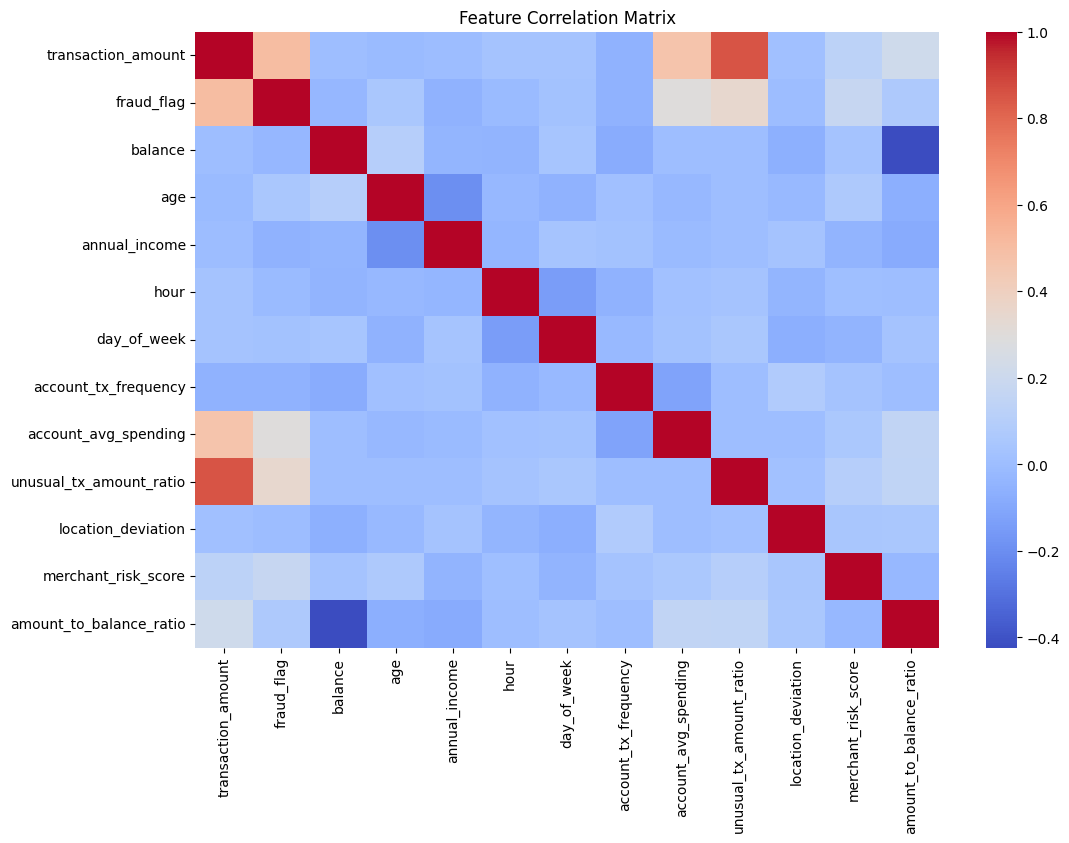

In [6]:
#Correlation Heatmap for numerical features
numeric_cols = df_feat.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_feat[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

## Model Building & Evaluation

In [7]:
def prep_data_for_modeling(df_feat):
    drop_cols = ['transaction_id', 'account_id', 'customer_id', 'timestamp']
    df_model = df_feat.drop(columns=[col for col in drop_cols if col in df_feat.columns], errors='ignore')
    
    df_model = df_model.fillna(0)

    categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns
    numerical_cols = df_model.select_dtypes(exclude=['object', 'category']).columns

    label_encoders = {}
    for col in categorical_cols:
        le_obj = LabelEncoder()
        df_model[col] = le_obj.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le_obj

    X = df_model.drop(columns=['fraud_flag'])
    y = df_model['fraud_flag']

    scaler_obj = StandardScaler()
    num_cols_to_scale = [col for col in numerical_cols if col != 'fraud_flag']
    X[num_cols_to_scale] = scaler_obj.fit_transform(X[num_cols_to_scale])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    return X_train, X_test, y_train, y_test, scaler_obj, label_encoders

X_train, X_test, y_train, y_test, scaler, le_dict = prep_data_for_modeling(df_feat)
print(f"X_train shape: {X_train.shape}")

X_train shape: (400, 19)


In [8]:
def evaluate_model(model_name, y_test, y_pred, y_prob=None):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    res = {'Model': model_name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
    if y_prob is not None:
         res['ROC-AUC'] = roc_auc_score(y_test, y_prob)
    else:
         res['ROC-AUC'] = 'N/A'
    return res

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    results.append(evaluate_model(name, y_test, y_pred, y_prob))
    trained_models[name] = model

# Unsupervised Isolation Forest baseline
iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(X_test)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)
results.append(evaluate_model("Isolation Forest", y_test, y_pred_iso))
trained_models["Isolation Forest"] = iso

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.99,1.000,0.833333,0.909091,0.973404
1,Random Forest,0.99,1.000,0.833333,0.909091,0.983156
2,XGBoost,0.96,0.625,0.833333,0.714286,0.989362
3,Isolation Forest,0.97,0.800,0.666667,0.727273,N/A


## 5. Model Serialization
Saving the best performing model based on F1 Score.

In [9]:
best_model_name = results_df.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Saving best model: {best_model_name}")

models_dir = "../models"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    
with open(os.path.join(models_dir, "best_fraud_model.pkl"), 'wb') as f:
    pickle.dump(best_model, f)
    
#Also save the scaler and label encoders for inference in Streamlit
with open(os.path.join(models_dir, "scaler.pkl"), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(models_dir, "label_encoders.pkl"), 'wb') as f:
    pickle.dump(le_dict, f)

print("Model serialization complete.")

Saving best model: Logistic Regression
Model serialization complete.
